# DIPm-TV — Real EDX data: Ge-Te-Sb nanocubes

Three-channel EDX reconstruction: **Ge** (channel 0), **Te** (channel 1), **Sb** (channel 2).  
Limited tilt: 16 projections over ±40°.  
Volume convention: `vol[depth, size_y, size_x]` — axis 0 = detector-row slab (DEPTH=176), axes 1-2 = reconstruction plane (IMG_SIZE=112).

Color convention: **Ge → red · Te → cyan/blue · Sb → green**

---
## Imports

In [1]:
import sys
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from pathlib import Path
from skimage.io import imread

sys.path.insert(0, '../../Src')
from radon import Radon3D
from dipm_tv import CNN3D, run_dipm_tv, preprocess_sinograms, save_results
from utils import norm_percentile, make_rgb_overlay

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {DEVICE}')
if DEVICE == 'cuda':
    torch.cuda.set_device(0)
    print(f'GPU    : {torch.cuda.get_device_name(0)}')

Device : cuda
GPU    : NVIDIA L40


---
## ▶ Choose EDX sample
Set `PREFIX` to `'Virgin'` or `'SET'`, then **Run All**.

In [2]:
# ╔══════════════════════════════════════════════╗
# ║           SAMPLE SELECTION                   ║
# ║  'Virgin'  →  as-fabricated                  ║
# ║  'SET'     →  programmed device              ║
# ╚══════════════════════════════════════════════╝
PREFIX = 'SET'

LABEL = PREFIX
print(f'Sample : {PREFIX}')

Sample : SET


## Configuration

In [3]:
# ---------------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------------
PHASE_NAMES = ['Ge', 'Te', 'Sb']

FULL_PATH = Path('../../Data/EDX_data')
OUT_DIR   = Path('../../Data/EDX_results') / PREFIX

# ---------------------------------------------------------------------------
# Tilt angles
# ---------------------------------------------------------------------------
THETA = [-40, -35, -30, -25, -20, -15, -10, -5, 0, 10, 15, 20, 25, 30, 35, 40]
print(f'[{LABEL}]  angles ({len(THETA)}) : {THETA}')

# ---------------------------------------------------------------------------
# Spatial dimensions
# ---------------------------------------------------------------------------
IMG_SIZE = 112
DEPTH    = 176

# ---------------------------------------------------------------------------
# Per-sample feature slice indices
#   vol shape: (DEPTH=176, IMG_SIZE=112, IMG_SIZE=112)
#   SL0 = axis-0 depth index  →  112×112 nanocube cross-section  (axis 0: 0-175)
#   SL1 = axis-1 img index    →  176×112 lateral view            (axis 1: 0-111)
#   SL2 = axis-2 img index    →  176×112 lateral view (MW dir.)  (axis 2: 0-111)
# ---------------------------------------------------------------------------
SAMPLE_SLICES = {
    'SET':    {'SL0': 129, 'SL1': 49, 'SL2': 79},
    'Virgin': {'SL0': 132, 'SL1': 55, 'SL2': 79},
}
SL = SAMPLE_SLICES[PREFIX]
SL0, SL1, SL2 = SL['SL0'], SL['SL1'], SL['SL2']
print(f'[{LABEL}]  feature slices → axis0={SL0}  axis1={SL1}  axis2={SL2}')

slice_views = [
    (lambda vol, s=SL0: vol[s, :, :],  f'depth={SL0}  (axis 0)'),
    (lambda vol, s=SL1: vol[:, s, :],  f'axis1={SL1}'),
    (lambda vol, s=SL2: vol[:, :, s],  f'axis2={SL2}'),
]

# Physical pixel size (nm/px)
PIXEL_SIZE_NM = 1.067   # 2.134 Å/px at acquisition, binned ×2

# ---------------------------------------------------------------------------
# DIPm-TV hyperparameters
# ---------------------------------------------------------------------------
UD_FILTERS    = [16,  32,  64, 128]
SKIP_FILTERS  = [ 4,   8,  16,  32]
NUM_ITER      = 1500
INPUT_DEPTH   = 32
LR            = 5e-4
NOISE_REG     = 0.05
STD_INP_NOISE = 0.1
EXP_WEIGHT    = 0.96
LAMBDA_TV     = 1e-11
LOSS_TYPE     = 'L2'
USE_AMP       = False
SAVE_EVERY    = 100
WEIGHT_DECAY  = 0.0

SIRT_ITERS = 50
PLOT_EVERY = 25

# ---------------------------------------------------------------------------
# Per-channel colormaps  (Ge=red, Te=cyan, Sb=green)
# ---------------------------------------------------------------------------
CMAPS = [
    LinearSegmentedColormap.from_list('ge', ['black', 'red']),    # Ge
    LinearSegmentedColormap.from_list('te', ['black', 'cyan']),   # Te
    LinearSegmentedColormap.from_list('sb', ['black', 'lime']),   # Sb
]

[SET]  angles (16) : [-40, -35, -30, -25, -20, -15, -10, -5, 0, 10, 15, 20, 25, 30, 35, 40]
[SET]  feature slices → axis0=129  axis1=49  axis2=79


## Load and preprocess data

In [4]:
# Load preprocessed projections — shape (N_angles, DEPTH, IMG_SIZE) per channel
data = np.stack([
    imread(str(FULL_PATH / f'{PREFIX}_{n}_proj.tif')) for n in PHASE_NAMES
]).astype(np.float32)
print(f'[{LABEL}]  loaded shape : {data.shape}  [N_ch, N_angles, DEPTH, IMG_SIZE]')

assert data.shape[2] == DEPTH and data.shape[3] == IMG_SIZE, (
    f'Shape mismatch: got {data.shape[2:]} expected ({DEPTH}, {IMG_SIZE})'
)

N_CH, N_ANGLES = data.shape[:2]

# Radon projector
rad_op = Radon3D(angle=np.deg2rad(THETA), size=IMG_SIZE, depth=DEPTH, device=DEVICE)

# Normalise per-channel + rearrange to (N_ch, depth, N_angles, img_size)
sino_torch, x_min, x_max = preprocess_sinograms(data, THETA, device=DEVICE)
print(f'sino_torch    : {sino_torch.shape}  [N_ch, depth, N_angles, img_size]')
print(f'x_min = {x_min}')
print(f'x_max = {x_max}')

[SET]  loaded shape : (3, 16, 176, 112)  [N_ch, N_angles, DEPTH, IMG_SIZE]
sino_torch    : torch.Size([3, 176, 16, 112])  [N_ch, depth, N_angles, img_size]
x_min = [0. 0. 0.]
x_max = [2.9315045 2.1587777 1.803016 ]


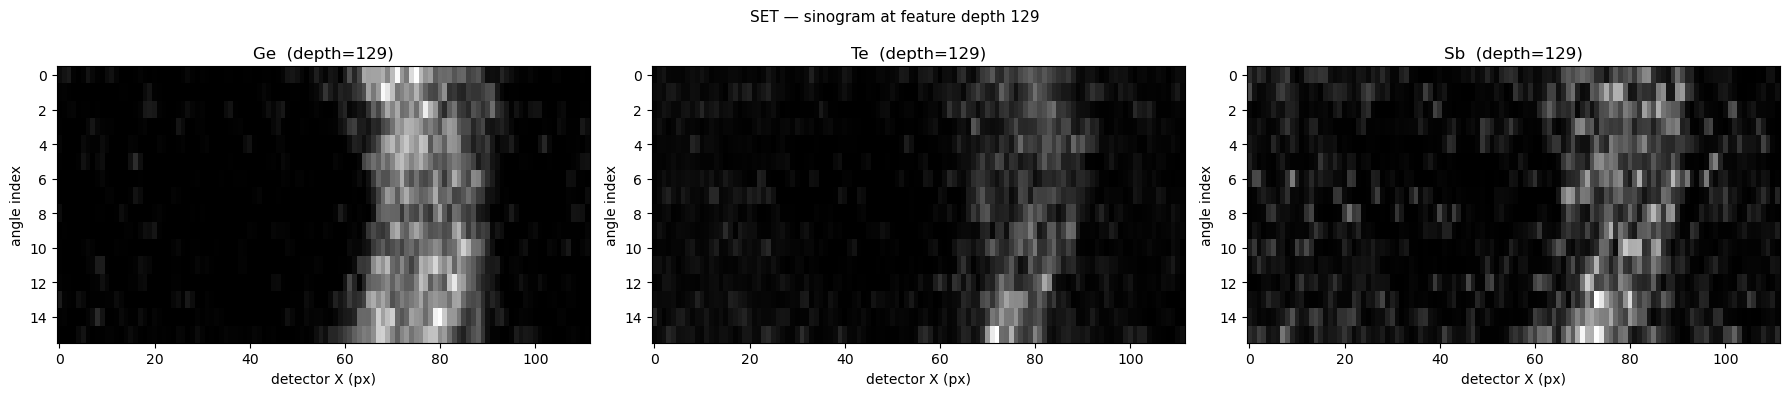

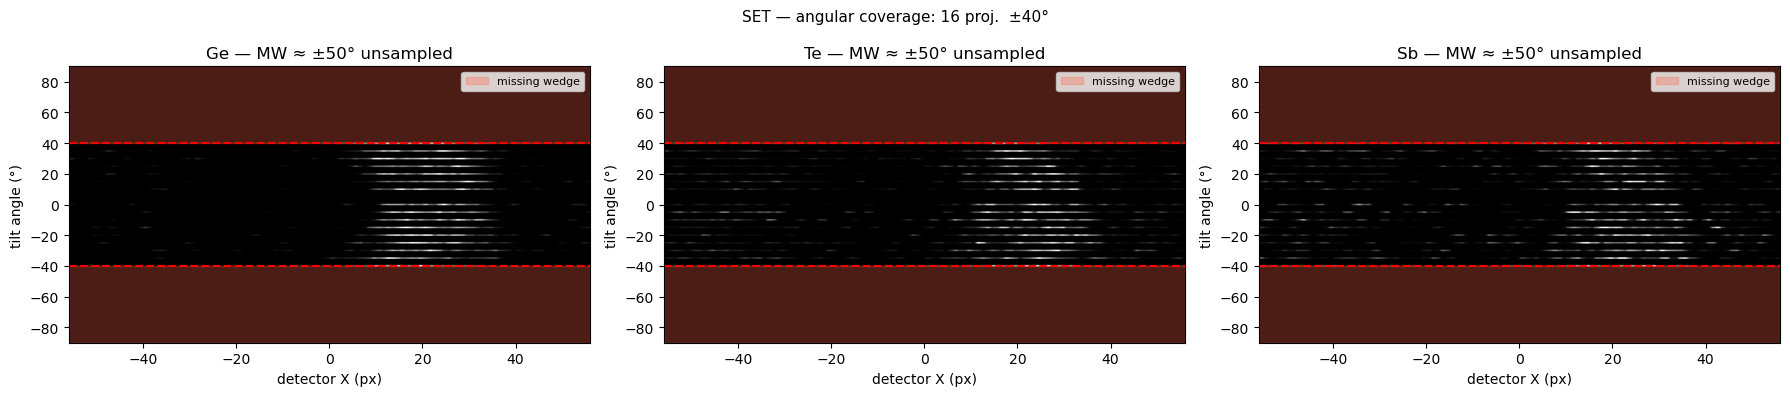

In [5]:
# Sinogram at feature depth SL0
fig, axes = plt.subplots(1, N_CH, figsize=(6 * N_CH, 4))
for i, (ax, name) in enumerate(zip(axes, PHASE_NAMES)):
    sl = sino_torch[i, SL0].detach().cpu().numpy()
    ax.imshow(sl, aspect='auto', cmap='gray')
    ax.set_title(f'{name}  (depth={SL0})')
    ax.set_xlabel('detector X (px)')
    ax.set_ylabel('angle index')
plt.suptitle(f'{LABEL} — sinogram at feature depth {SL0}', fontsize=11)
plt.tight_layout()
plt.show()

# Missing-wedge coverage map
ang_axis = np.linspace(-90, 90, 181)
fig2, axes2 = plt.subplots(1, N_CH, figsize=(6 * N_CH, 4))
for i, (ax, name) in enumerate(zip(axes2, PHASE_NAMES)):
    sl = sino_torch[i, SL0].detach().cpu().numpy()
    full_sino = np.zeros((len(ang_axis), IMG_SIZE), dtype=np.float32)
    for j, theta in enumerate(THETA):
        idx = np.argmin(np.abs(ang_axis - theta))
        row = sl[j]
        full_sino[idx] = (row - row.min()) / (row.max() - row.min() + 1e-9)
    ax.imshow(full_sino, aspect='auto', cmap='gray', origin='lower',
              extent=[-IMG_SIZE // 2, IMG_SIZE // 2, -90, 90], vmin=0, vmax=1)
    ax.axhspan(-90, THETA[0],  alpha=0.3, color='tomato', label='missing wedge')
    ax.axhspan(THETA[-1], 90,  alpha=0.3, color='tomato')
    ax.axhline(THETA[0],  color='red', lw=1.5, ls='--')
    ax.axhline(THETA[-1], color='red', lw=1.5, ls='--')
    ax.set_title(f'{name} — MW ≈ ±{90 - np.abs(THETA).max():.0f}° unsampled')
    ax.set_xlabel('detector X (px)')
    ax.set_ylabel('tilt angle (°)')
    ax.legend(fontsize=8, loc='upper right')
plt.suptitle(
    f'{LABEL} — angular coverage: {N_ANGLES} proj.  ±{np.abs(THETA).max():.0f}°',
    fontsize=11,
)
plt.tight_layout()
plt.show()

## SIRT reconstruction:

In [6]:
#SIRT reconstruction for channel
sirt_list = []
for i in range(N_CH):
    vol = rad_op.backward_sirt_ts(
        sino_torch[i],
        progress_bar=True,
        num_iters=SIRT_ITERS,
    ).detach().cpu().numpy()   # (depth, img_size, img_size)
    vol = vol * (x_max[i] - x_min[i]) + x_min[i]
    sirt_list.append(vol)
    print(f'[{LABEL}]  SIRT {PHASE_NAMES[i]:3s}  '
          f'shape={vol.shape}  min={vol.min():.4g}  max={vol.max():.4g}')

100%|██████████| 50/50 [00:00<00:00, 558.97it/s]


[SET]  SIRT Ge   shape=(176, 112, 112)  min=0  max=9.719


100%|██████████| 50/50 [00:00<00:00, 669.05it/s]


[SET]  SIRT Te   shape=(176, 112, 112)  min=0  max=7.736


100%|██████████| 50/50 [00:00<00:00, 678.11it/s]

[SET]  SIRT Sb   shape=(176, 112, 112)  min=0  max=7.439


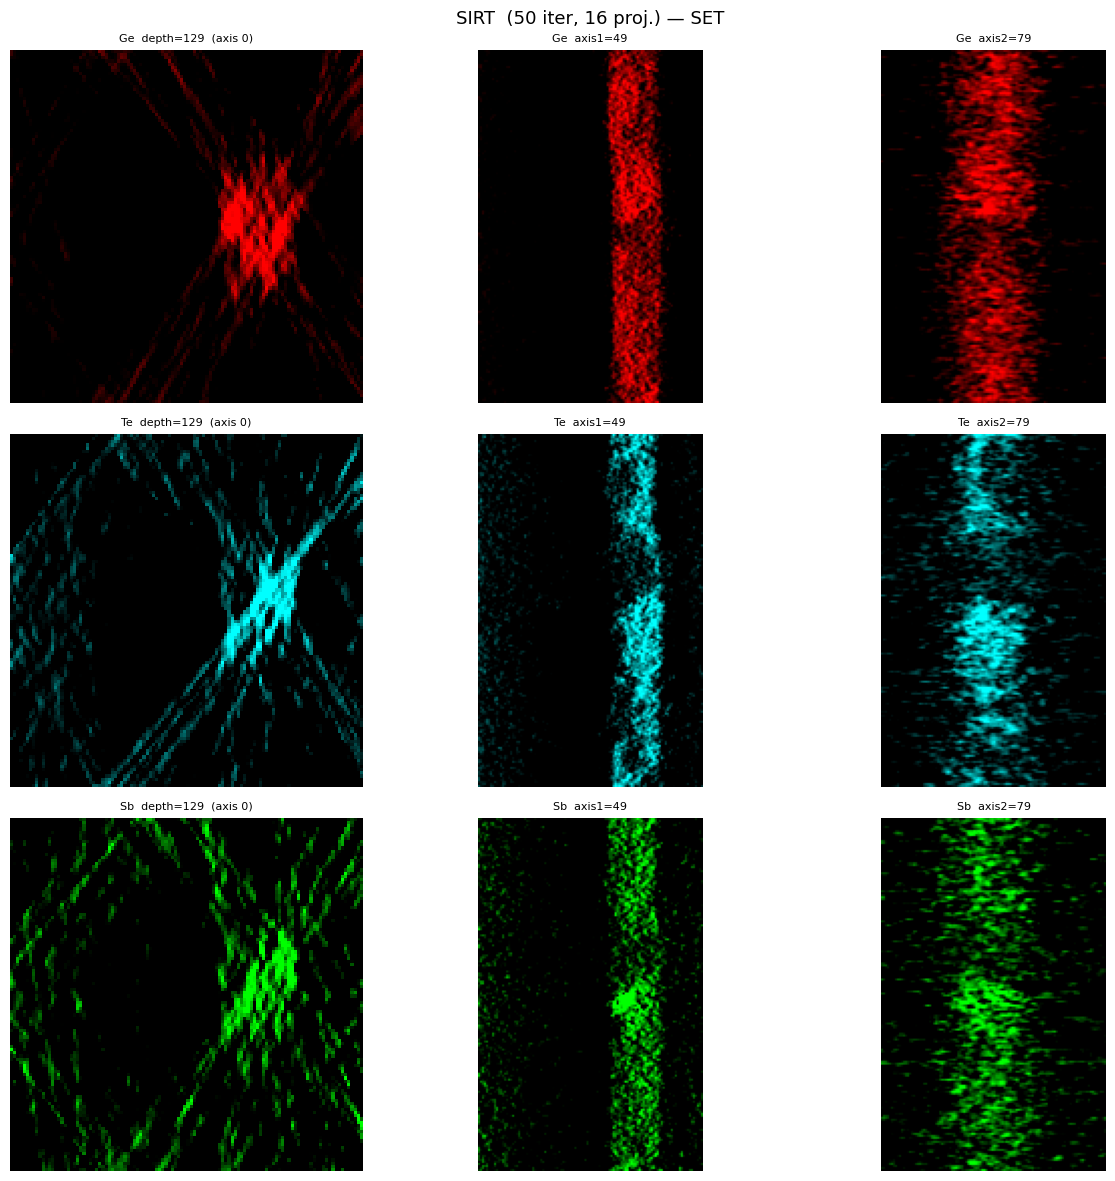

In [7]:
fig, axes = plt.subplots(N_CH, 3, figsize=(13, 4 * N_CH))
for i, name in enumerate(PHASE_NAMES):
    for j, (sl_fn, sl_lbl) in enumerate(slice_views):
        axes[i, j].imshow(norm_percentile(sl_fn(sirt_list[i])), cmap=CMAPS[i])
        axes[i, j].set_title(f'{name}  {sl_lbl}', fontsize=8)
        axes[i, j].axis('off')
plt.suptitle(f'SIRT  ({SIRT_ITERS} iter, {N_ANGLES} proj.) — {LABEL}', fontsize=13)
plt.tight_layout()
plt.show()

## DIPm-TV reconstruction

In [8]:
n_scale = len(UD_FILTERS)
net = CNN3D(
    nbr             = N_CH,
    input_shape     = INPUT_DEPTH,
    down_filters    = UD_FILTERS,
    up_filters      = UD_FILTERS,
    skip_filters    = SKIP_FILTERS,
    down_kernels    = [3] * n_scale,
    up_kernels      = [3] * n_scale,
    skip_kernels    = [1] * n_scale,
    up_mode         = 'trilinear',
    pad_mode        = 'reflect',
    force_non_zeros = True,
).to(DEVICE)

sirt_vol = torch.stack([
    torch.from_numpy(v).float() for v in sirt_list
])   # (N_ch, depth, img_size, img_size)

Training DIPm-TV on SET — 1500 iter
Output / Input img size : torch.Size([1, 32, 176, 112, 112])
network parameters: 1_807_919
image size : 6_623_232


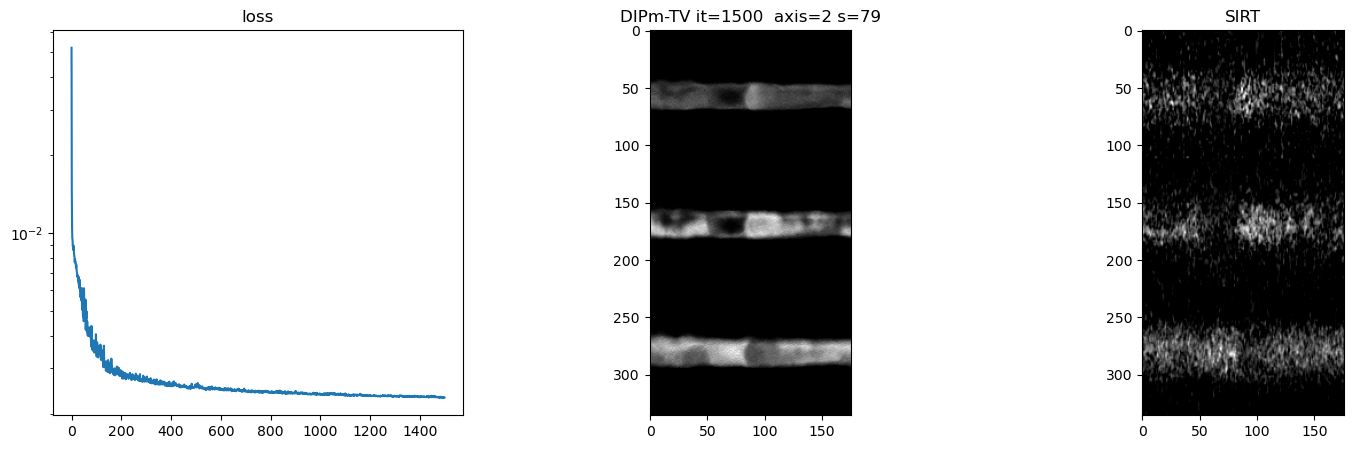

DIP-MTV: 100%|██████████| 1500/1500 [03:53<00:00,  6.42it/s]

Total time: 0:03:53.790093


In [9]:
print(f'Training DIPm-TV on {LABEL} — {NUM_ITER} iter')

iter_out, loss_vals = run_dipm_tv(
    net,
    rad_op,
    sino_torch,
    sirt_vol      = sirt_vol,
    num_iter      = NUM_ITER,
    input_depth   = INPUT_DEPTH,
    depth         = DEPTH,
    img_size      = IMG_SIZE,
    lr            = LR,
    noise_reg     = NOISE_REG,
    exp_weight    = EXP_WEIGHT,
    lambda_tv     = LAMBDA_TV,
    loss_type     = LOSS_TYPE,
    std_inp_noise = STD_INP_NOISE,
    weight_decay  = WEIGHT_DECAY,
    use_amp       = USE_AMP,
    plot_every    = PLOT_EVERY,
    plot_slice    = 79,   # feature depth slice → 112×112 preview
    plot_axis     = 2,
    save_every    = SAVE_EVERY,
    device        = DEVICE,
)

## Results

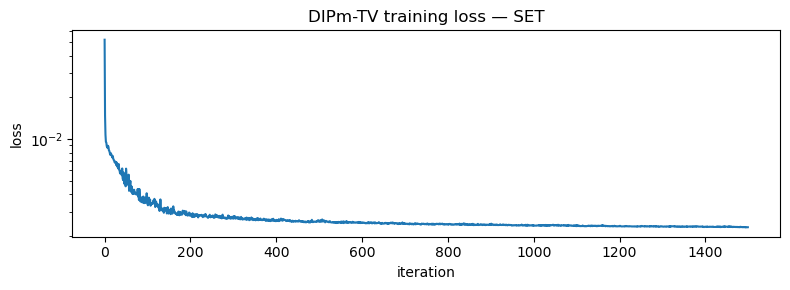

In [10]:
plt.figure(figsize=(8, 3))
plt.semilogy(loss_vals)
plt.xlabel('iteration')
plt.ylabel('loss')
plt.title(f'DIPm-TV training loss — {LABEL}')
plt.tight_layout()
plt.show()

In [11]:
# Denormalise final reconstruction to original sinogram intensity scale
rec_norm = iter_out[-1][1]   # (N_ch, depth, img_size, img_size)
rec = rec_norm.copy()
for i in range(N_CH):
    rec[i] = rec[i] * (x_max[i] - x_min[i]) + x_min[i]

### Three-view panel: SIRT vs DIPm-TV

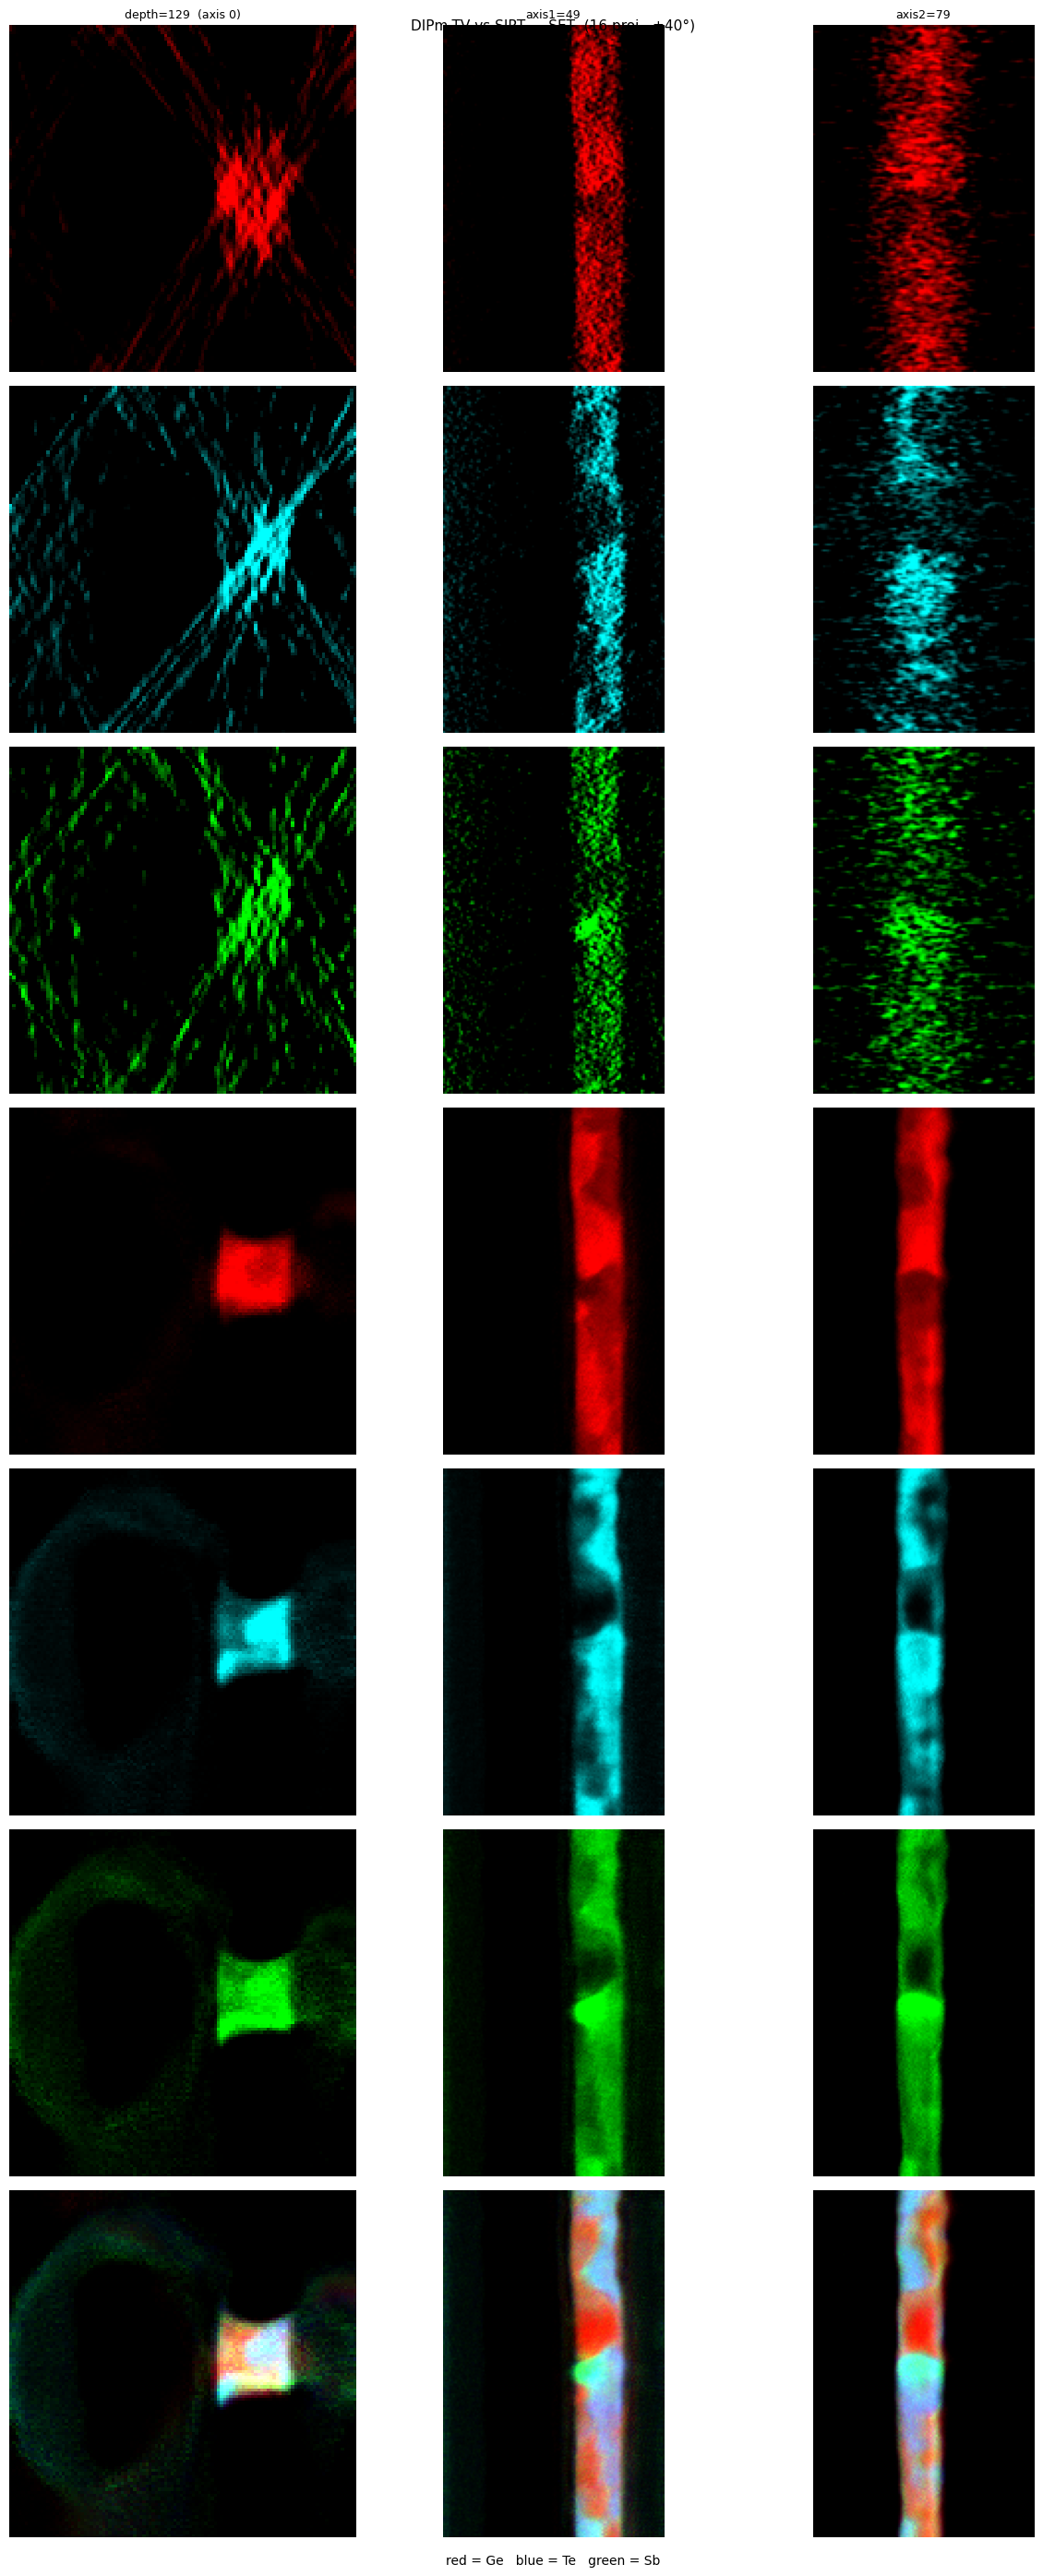

In [12]:
rows_def = [
    (f'SIRT Ge',      sirt_list[0], CMAPS[0]),
    (f'SIRT Te',      sirt_list[1], CMAPS[1]),
    (f'SIRT Sb',      sirt_list[2], CMAPS[2]),
    (f'DIPm-TV Ge',   rec[0],       CMAPS[0]),
    (f'DIPm-TV Te',   rec[1],       CMAPS[1]),
    (f'DIPm-TV Sb',   rec[2],       CMAPS[2]),
    ('RGB overlay',   None,          None),
]

fig, axes = plt.subplots(len(rows_def), 3, figsize=(13, 4 * len(rows_def)))

for col, (sl_fn, sl_lbl) in enumerate(slice_views):
    for row, (lbl, vol, cmap) in enumerate(rows_def):
        ax = axes[row, col]
        if vol is None:
            # Ge → R, Sb → G, Te → B
            ax.imshow(make_rgb_overlay(sl_fn(rec[0]), sl_fn(rec[2]), sl_fn(rec[1])))
        else:
            ax.imshow(norm_percentile(sl_fn(vol)), cmap=cmap, vmin=0, vmax=1)
        if row == 0:
            ax.set_title(sl_lbl, fontsize=9)
        ax.set_ylabel(lbl, fontsize=8)
        ax.axis('off')

fig.text(0.5, -0.005, 'red = Ge   blue = Te   green = Sb', ha='center', fontsize=10)
plt.suptitle(
    f'DIPm-TV vs SIRT — {LABEL}  ({N_ANGLES} proj., ±{np.abs(THETA).max():.0f}°)',
    fontsize=11,
)
plt.tight_layout()
plt.show()

### Per-channel comparison: SIRT vs DIPm-TV

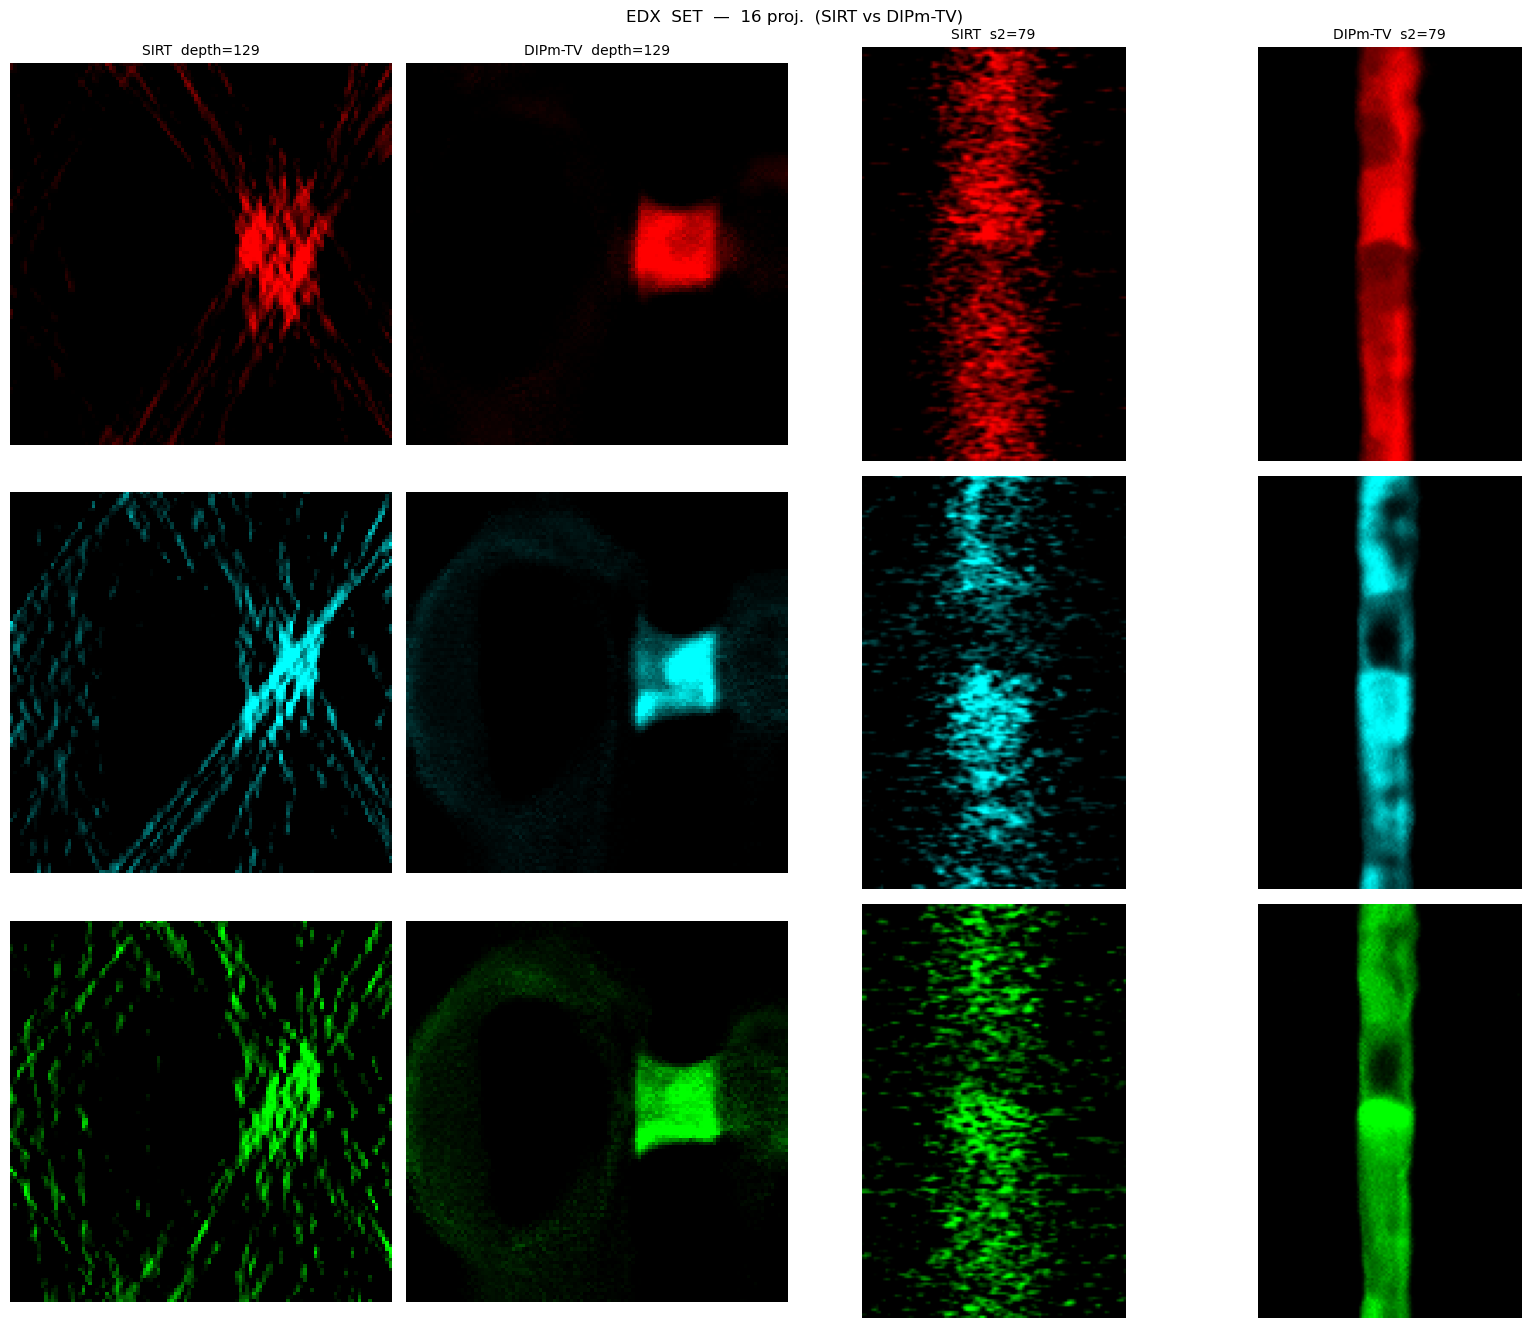

In [13]:
fig, axes = plt.subplots(N_CH, 4, figsize=(16, 4.5 * N_CH))
col_titles = [
    f'SIRT  depth={SL0}', f'DIPm-TV  depth={SL0}',
    f'SIRT  s2={SL2}',    f'DIPm-TV  s2={SL2}',
]
for j, ct in enumerate(col_titles):
    axes[0, j].set_title(ct, fontsize=10)

for i, name in enumerate(PHASE_NAMES):
    sv, dv = sirt_list[i], rec[i]
    for j, sl in enumerate([
        norm_percentile(sv[SL0, :, :]), norm_percentile(dv[SL0, :, :]),
        norm_percentile(sv[:, :, SL2]), norm_percentile(dv[:, :, SL2]),
    ]):
        axes[i, j].imshow(sl, cmap=CMAPS[i], vmin=0, vmax=1)
        axes[i, j].set_ylabel(name, fontsize=10)
        axes[i, j].axis('off')

plt.suptitle(f'EDX  {LABEL}  —  {N_ANGLES} proj.  (SIRT vs DIPm-TV)', fontsize=12)
plt.tight_layout()
plt.show()

### RGB overlay  (Ge=red, Te=blue, Sb=green)

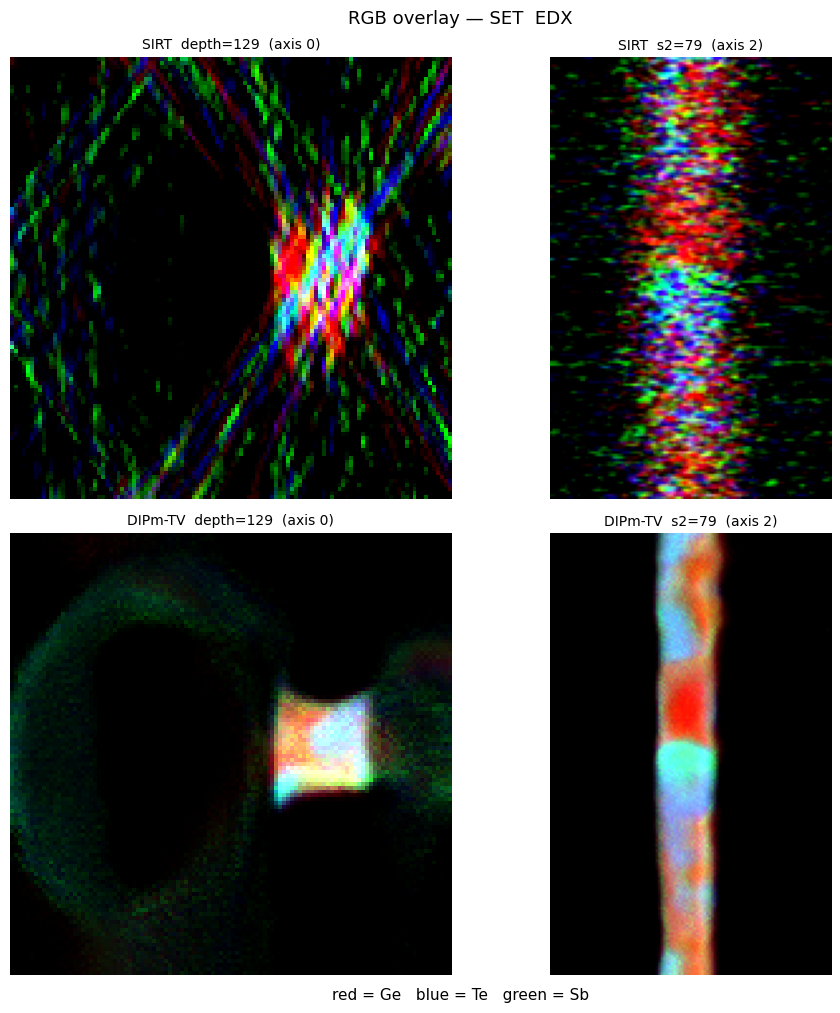

In [14]:
view_pairs = [
    (lambda v: v[SL0, :, :], f'depth={SL0}  (axis 0)'),
    (lambda v: v[:, :, SL2], f's2={SL2}  (axis 2)'),
]

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
for row, (vols, method) in enumerate([
    (sirt_list,            'SIRT'),
    ([rec[0], rec[1], rec[2]], 'DIPm-TV'),
]):
    for col, (sl_fn, sl_lbl) in enumerate(view_pairs):
        # Ge → R, Sb → G, Te → B
        axes[row, col].imshow(make_rgb_overlay(sl_fn(vols[0]), sl_fn(vols[2]), sl_fn(vols[1])))
        axes[row, col].set_title(f'{method}  {sl_lbl}', fontsize=10)
        axes[row, col].axis('off')

fig.text(0.5, -0.01, 'red = Ge   blue = Te   green = Sb', ha='center', fontsize=11)
plt.suptitle(f'RGB overlay — {LABEL}  EDX', fontsize=13)
plt.tight_layout()
plt.show()

## Save results

In [15]:
save_results(
    iter_out,
    phase_names = PHASE_NAMES,
    out_dir     = OUT_DIR,
    x_min       = x_min,
    x_max       = x_max,
    sample      = PREFIX,
    lambda_tv   = LAMBDA_TV,
    lr          = LR,
    noise_reg   = NOISE_REG,
    loss_type   = LOSS_TYPE,
)
print(f'[{LABEL}]  saved to {OUT_DIR}')

Saved: ..\..\Data\EDX_results\SET\DIP_recon_SET_Ge_it1499_tv1e-11_lr0.0005_nr0.05_L2.tif  shape(Z,Y,X)=(176, 112, 112)
Saved: ..\..\Data\EDX_results\SET\DIP_recon_SET_Te_it1499_tv1e-11_lr0.0005_nr0.05_L2.tif  shape(Z,Y,X)=(176, 112, 112)
Saved: ..\..\Data\EDX_results\SET\DIP_recon_SET_Sb_it1499_tv1e-11_lr0.0005_nr0.05_L2.tif  shape(Z,Y,X)=(176, 112, 112)
[SET]  saved to ..\..\Data\EDX_results\SET
